In [1]:
import numpy as np
import harmonica as hm
import bordado as bd
import boule as bl
import verde as vd
import matplotlib.pyplot as plt
import spherical as sph
import pandas as pd

In [2]:
def fit(coordinates, data, eqs_source_coords, damping, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):

    A = sph.jacobian(
        coordinates, 
        eqs_source_coords,
        eqs_inc, eqs_dec,
        inclination_main_field, declination_main_field
    )
    
    eqs_dipole_moment_amplitude = sph.calculate_coefficients(
        data, A, damping=damping,
    )
    return eqs_dipole_moment_amplitude

def shallow_dipole_moment_amp(coordinates, equivalent_layer, window_size, damping, residuals, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):
    
    sph_coordinates =  bl.WGS84.geodetic_to_spherical(coordinates[0], coordinates[1], coordinates[2])
    sph_dipoles = bl.WGS84.geodetic_to_spherical(equivalent_layer[0], equivalent_layer[1], equivalent_layer[2])

    _, source_indices = vd.rolling_window(sph_dipoles, size=window_size, spacing=window_size / 2)
    _, data_indices = vd.rolling_window(sph_coordinates, size=window_size, spacing=window_size / 2)

    source_indices = [i[0] for i in source_indices.ravel()]
    data_indices = [i[0] for i in data_indices.ravel()]

    residuals_shallow = residuals.copy()
    dipole_moment_amp = np.zeros_like(equivalent_layer[0])

    window_indices = list(range(len(data_indices)))

    np.random.shuffle(window_indices)
    
    for i in window_indices:
        data_coord = tuple(c[data_indices[i]] for c in sph_coordinates)
        source_coord = tuple(c[source_indices[i]] for c in sph_dipoles)

        eqs_dipole_moment_amp = fit(
            data_coord,
            residuals_shallow[data_indices[i]],
            source_coord,
            damping,
            eqs_inc,
            eqs_dec,
            inclination_main_field,
            declination_main_field
        )

        dipole_moment_amp[source_indices[i]] += eqs_dipole_moment_amp
        eqs_dipole_moment =  hm.magnetic_angles_to_vec(
            eqs_dipole_moment_amp,eqs_inc, eqs_dec)


        predicted_total_field_anomaly = hm.total_field_anomaly(
            sph.dipole_magnetic_spherical(sph_coordinates, source_coord, eqs_dipole_moment),
                inclination_main_field, declination_main_field)
        residuals_shallow -= predicted_total_field_anomaly

    eqs_vector = hm.magnetic_angles_to_vec(dipole_moment_amp, eqs_inc, eqs_dec)

    eqs_vector_geod = sph.spherical_to_geodetic(sph_dipoles[1], equivalent_layer[1], eqs_vector[0],eqs_vector[1], eqs_vector[2])

    return eqs_vector_geod

def deep_dipole_moment(coordinates, deep_eqs_coords,data, eqs_inc, eqs_dec, damping,  inclination_main_field, declination_main_field):

    sph_coordinates =  bl.WGS84.geodetic_to_spherical(coordinates[0], coordinates[1], coordinates[2])
    sph_dipoles = bl.WGS84.geodetic_to_spherical(deep_eqs_coords[0], deep_eqs_coords[1], deep_eqs_coords[2])

    deep_dipole_moment_amp = fit(
        coordinates=sph_coordinates,
        data=data,
        eqs_source_coords= sph_dipoles,
        damping=damping,
        eqs_inc=eqs_inc,
        eqs_dec=eqs_dec,
        inclination_main_field=inclination_main_field,
        declination_main_field=declination_main_field)

    eqs_vector_deep =  hm.magnetic_angles_to_vec(deep_dipole_moment_amp,eqs_inc, eqs_dec)
    
    eqs_vector_deep_geod = sph.spherical_to_geodetic(sph_dipoles[1], deep_eqs_coords[1], eqs_vector_deep[0],eqs_vector_deep[1], eqs_vector_deep[2])

    return eqs_vector_deep_geod

def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
    
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)


    dipole_latitudes, dipole_longitudes, dipole_radii = dipole_data

    for lat, lon, r, moment in zip(dipole_latitudes.flatten(), dipole_longitudes.flatten(), dipole_radii.flatten(), moments):
        dipole_coordinates = np.array([lat, lon, r])
        
        magnetic_field = sph.dipole_magnetic_geodetic(
            grid_coord,
            dipole_coordinates,
            moment
        )
        
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

    return grided_magnetic_anomaly

In [3]:
df = pd.read_csv(
    "/home/arthur/Documentos/ANP_MAG/blockmedian_alt.csv", sep = '	', 
)

df.columns = ['long', 'lat', 'height']

df2 = pd.read_csv( "/home/arthur/Documentos/ANP_MAG/blockmedian_mag.csv", sep = '	', 

)

df2.columns = ['long', 'lat', 'mag']

df = pd.merge(df, df2, on=['long', 'lat'])

df

,long,lat,height,mag
0,-52.879747,-14.021349,1833.490,-134.6030
1,-52.936638,-14.029996,1829.980,-139.8650
2,-52.879359,-14.029999,1832.580,-137.8685
3,-52.936532,-14.040001,1830.240,-143.1720
4,-52.879200,-14.040002,1835.830,-141.4190
...,...,...,...,...
152522,-53.635231,-24.409443,1797.515,-59.2815
152523,-53.575943,-24.408768,1788.480,-67.6960
152524,-53.517355,-24.408011,1801.730,-91.0270
152525,-53.872220,-24.416813,1798.740,-41.3835


In [4]:
lon = df["long"].values
lat = df["lat"].values
height = df["height"].values


reducer = vd.BlockReduce(reduction=np.median, spacing= 0.03)

coordinates, height_new = reducer.filter(
    (df.long, df.lat), df.height
)
lon, lat = coordinates

coordinates = (lon, lat, height_new)

print(coordinates[0].size)

45840


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.10/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f6a90339fc0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.10/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7f6a90339fc0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


In [97]:
# lon = df["long"].values
# lat = df["lat"].values
# height = df["height"].values

# coordinates = (lon, lat, height)

inclination, declination = -25, -20  
noise_level = 1

#Source 1 
source1a = sph.profile_points((-57,-14),(-54,-15.5), 1000, - 30e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, 5e10), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source1a, magnetic_moment)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

source1b = sph.profile_points((-57,-16),(-48,-13), 1000, - 30e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, 5e10), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source1b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 2 
source2a= sph.profile_points((-52,-16),(-53,-16), 300, - 25e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(300, 3e10), np.full(300, inclination),np.full(300, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source2a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source2b= sph.profile_points((-54,-16.7),(-53,-16.7), 300,- 22e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(300, 3e10), np.full(300, inclination),np.full(300, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source2b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 3
source3= sph.profile_points((-54,-17.5),(-54.5,-17.5), 150, - 20e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(150, 3e10), np.full(150, inclination),np.full(150, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source3, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 4
source4a= sph.profile_points((-54,-20),(-53.5,-19), 250, - 17e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source4a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source4b= sph.profile_points((-54.5,-19.5),(-54,-18.5), 250, - 16e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source4b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source4c= sph.profile_points((-54.6,-20.4),(-54.6,-20.4), 100, - 13e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(100, 3e10), np.full(100, inclination),np.full(100, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source4c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 5
source5a= sph.profile_points((-52,-19),(-49,-19), 250, - 15e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5b= sph.profile_points((-50,-19.6),(-48,-19.6), 250, - 14e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5c= sph.profile_points((-48,-20),(-45,-20), 250,- 15e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5d= sph.profile_points((-45,-20.4),(-48,-20.4), 250, - 13e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5d, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5e= sph.profile_points((-45,-20.9),(-48,-20.9), 250, - 12e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5e, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source5f= sph.profile_points((-45,-13),(-52,-18.9), 500, - 11e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(500, 3e10), np.full(500, inclination),np.full(500, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5f, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

# source5g_dipole= sph.profile_points((-52.3,-19.6),(-52.3,-19.6), 5, -12e3)
# magnetic_moment = hm.magnetic_angles_to_vec(np.full(5,8e11), np.full(5,45), np.full(5,0))
# magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source5g_dipole, magnetic_moment)
# magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 6
source6a= sph.profile_points((-48,-20.9),(-51,-23.9), 250, - 15e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source6a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source6b= sph.profile_points((-47,-20.9),(-50,-24.9), 250, - 14e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source6b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source6c= sph.profile_points((-51.4,-22),(-50.2,-21), 250,- 13e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, 3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source6c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 7
source7a= sph.profile_points((-52,-16),(-53.8,-21), 250,- 12e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(250, -3e10), np.full(250, inclination),np.full(250, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source7a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 8 
source8a= sph.profile_points((-57,-26.5),(-54,-23.1), 400, - 15e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(400, -9e10), np.full(400, inclination),np.full(400, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source8a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Source 9
source9a= sph.profile_points((-48,-26.5),(-54,-22), 1000, - 6e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, -2e9), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source9a, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source9b= sph.profile_points((-46.5,-26.4),(-51.5,-22.2), 1000, - 3e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, -2e9), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source9b, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source9c= sph.profile_points((-48,-26.6),(-51,-22.5), 1000, - 5e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, -2e9), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source9c, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

source9d= sph.profile_points((-51.4,-19),(-45,-26.5), 1000, - 4e3)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(1000, -2e9), np.full(1000, inclination),np.full(1000, declination))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source9d, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Regional Field
regional= vd.scatter_points(region=(-55,-50,-23,-17), size=90, extra_coords=-60e3, random_state=1)
magnetic_moment = hm.magnetic_angles_to_vec(np.full(90, -2e13), np.full(90, -90),np.full(90, 45))
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, regional, magnetic_moment)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

#Random noise
magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-57.083495788875),
 np.float64(-46.336509508625),
 np.float64(-24.932321735499997),
 np.float64(-13.5160806795))

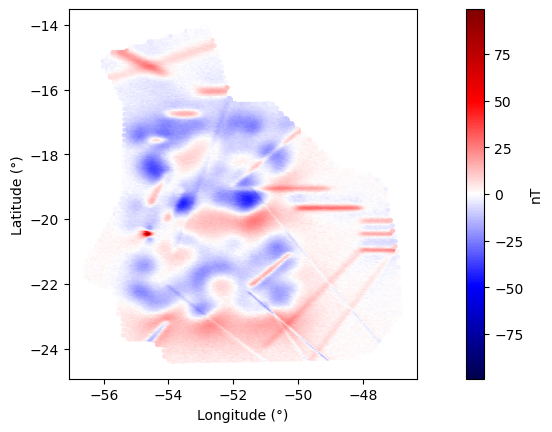

In [98]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.10/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f6a90339fc0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.10/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7f6a90339fc0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


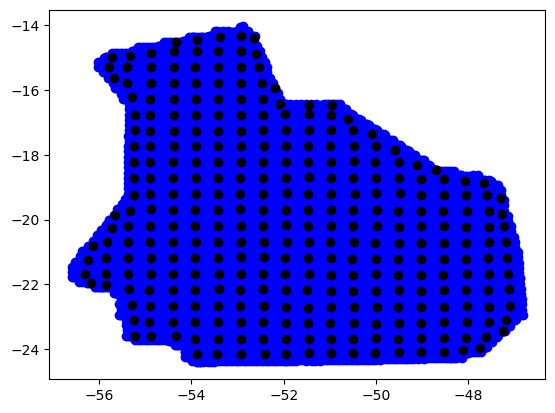

In [99]:
reducer = vd.BlockReduce(reduction=np.median, spacing=0.5,  center_coordinates=False, drop_coords=False)
points, magnetic_anomaly_reduced = reducer.filter(coordinates, magnetic_anomaly)
eqs_source_coords_deep = list(points)
eqs_source_coords_deep[2] = points[2] - 60e3


# print(points)


plt.plot(*coordinates[:2], "ob")
plt.plot(*eqs_source_coords_deep[:2], "ok")
plt.show()

damping_deep = 1e-30
eqs_inc = 90
eqs_dec = 0
eqs_dipole_unit = hm.magnetic_angles_to_vec(1,eqs_inc, eqs_dec)

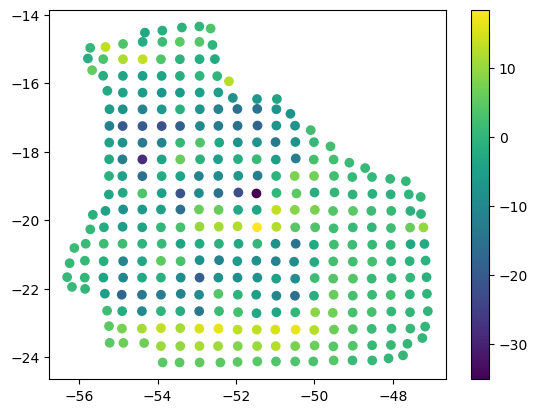

In [100]:
plt.scatter(*points[:2], c = magnetic_anomaly_reduced)
plt.colorbar()

In [101]:
dipole_moment_deep = deep_dipole_moment(
    coordinates=points,
    data=magnetic_anomaly_reduced,
    deep_eqs_coords=eqs_source_coords_deep,
    damping=damping_deep,
    eqs_inc=eqs_inc,
    eqs_dec=eqs_dec,
    inclination_main_field=inclination,
    declination_main_field=declination
)

In [102]:
predicted_magnetic_field_deep =  hm.total_field_anomaly(
    sph.dipole_magnetic_geodetic(
        coordinates, eqs_source_coords_deep, dipole_moment_deep
    ),
    inclination, 
    declination,
)

residuals_deep = magnetic_anomaly - predicted_magnetic_field_deep


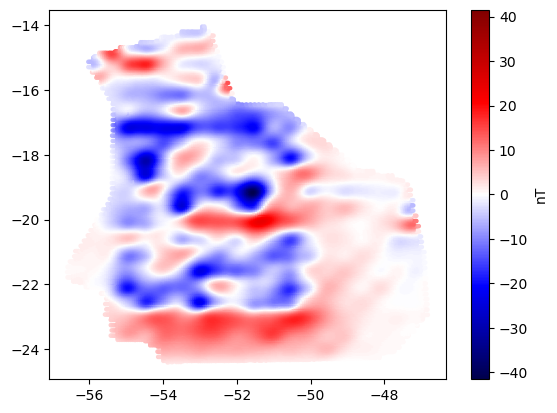

In [103]:
scale_deep = vd.maxabs(predicted_magnetic_field_deep)
plt.scatter(coordinates[0], coordinates[1],c = predicted_magnetic_field_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

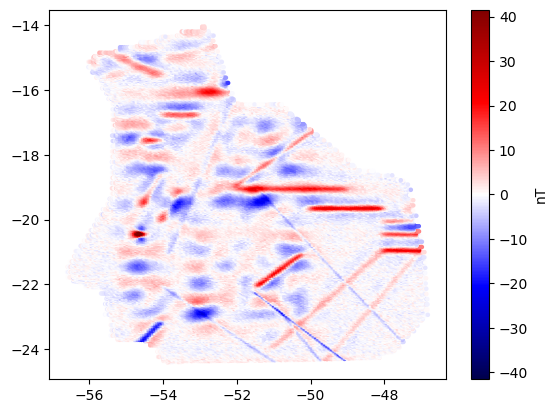

In [104]:
plt.scatter(coordinates[0], coordinates[1],c = residuals_deep, s = 5,cmap="seismic", vmin=-scale_deep, vmax=scale_deep)
plt.colorbar(label='nT')

In [112]:
window_size = 1

damping_shallow = 1e-18

equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 8e3
)

dipole_moment_shallow = shallow_dipole_moment_amp(coordinates, equivalent_layer, window_size, damping_shallow, residuals_deep, eqs_inc, eqs_dec, inclination, declination)

In [113]:
predicted_magnetic_field_shallow =  hm.total_field_anomaly(
    sph.dipole_magnetic_geodetic(
        coordinates, equivalent_layer, dipole_moment_shallow
    ),
    inclination, 
    declination,
)

residuals_shallow = magnetic_anomaly - predicted_magnetic_field_shallow

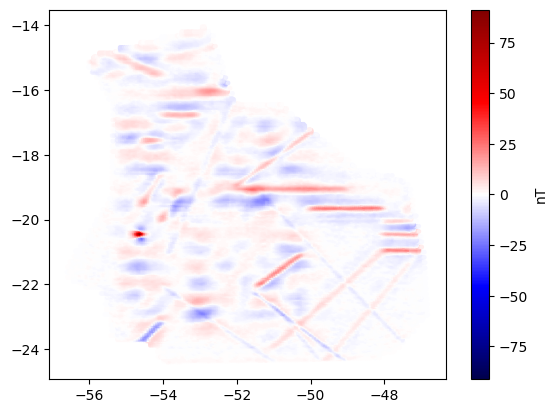

In [114]:
scale_shallow = vd.maxabs(predicted_magnetic_field_shallow)
plt.scatter(coordinates[0], coordinates[1],c = predicted_magnetic_field_shallow, s = 5,cmap="seismic", vmin=-scale_shallow, vmax=scale_shallow)
plt.colorbar(label='nT')

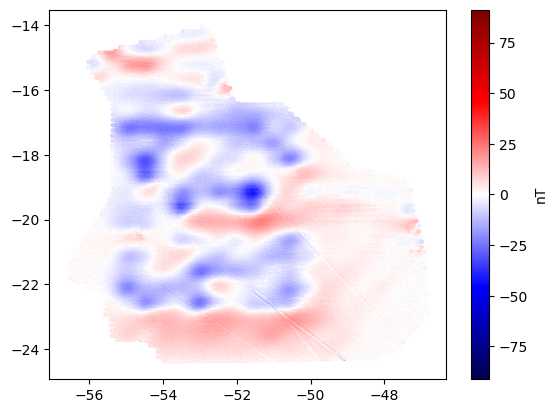

In [115]:
plt.scatter(coordinates[0], coordinates[1],c = residuals_shallow, s = 5,cmap="seismic", vmin=-scale_shallow, vmax=scale_shallow)
plt.colorbar(label='nT')

In [116]:
grid_coord = vd.grid_coordinates((-57, -46, -26, -13), shape=(150, 150), extra_coords= 500)

# Source 1
grided_dd_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, source1a, np.full(1000, 5e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source1b, np.full(1000, 5e10))

# Source 2
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source2a, np.full(300, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source2b, np.full(300, 3e10))

# Source 3
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source3, np.full(150, 3e10))

# Source 4
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4a, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4b, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source4c, np.full(100, 3e10))

# Source 5
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5a, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5b, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5c, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5d, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5e, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source5f, np.full(500, 3e10))
# grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, 45, 0, source5g_dipole, np.full(5, 8e10))


# Source 6
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6a, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6b, np.full(250, 3e10))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source6c, np.full(250, 3e10))

# Source 7
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source7a, np.full(250, -3e10))

# Source 8
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source8a, np.full(400, -9e10))

# Source 9
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9a, np.full(1000, -2e9))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9b, np.full(1000, -2e9))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9c, np.full(1000, -2e9))
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, inclination, declination, source9d, np.full(1000, -2e9))

# Regional 
grided_dd_anomaly += compute_magnetic_anomaly(grid_coord, -90, 45, regional, np.full(90, -5e12))

In [117]:
predicted_total_field_grid =  hm.total_field_anomaly(
    sph.dipole_magnetic_geodetic(
        grid_coord, equivalent_layer, dipole_moment_shallow
    ),
    inclination, 
    declination,
)

predicted_total_field_grid +=  hm.total_field_anomaly(
    sph.dipole_magnetic_geodetic(
        grid_coord, eqs_source_coords_deep, dipole_moment_deep
    ),
    inclination, 
    declination,
)

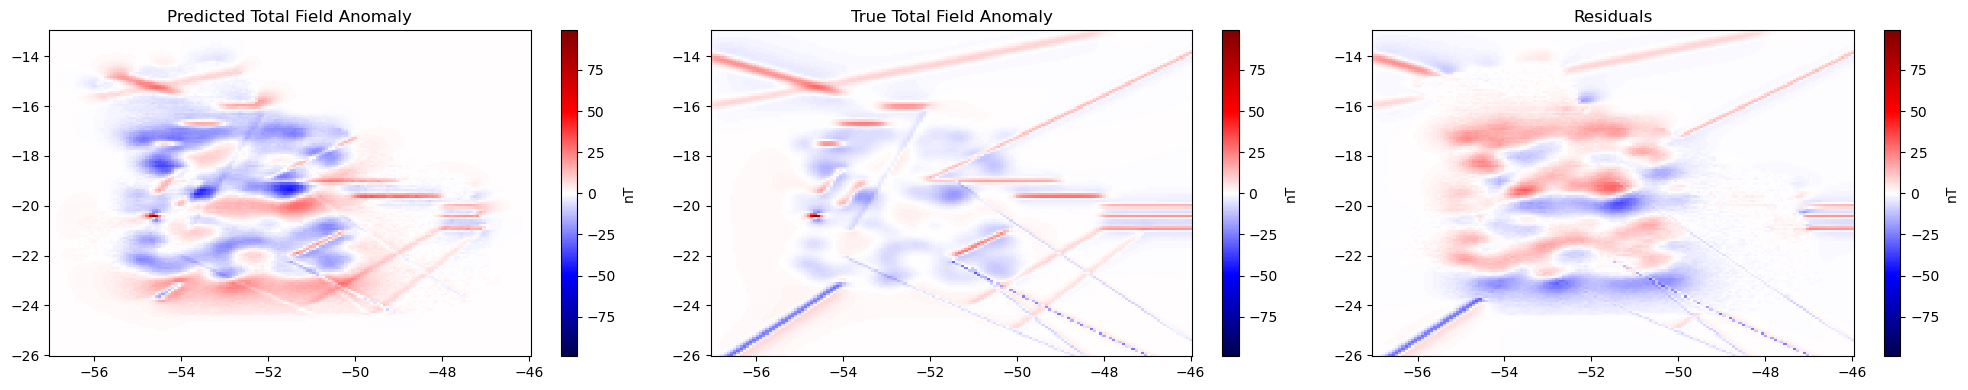

In [118]:
diff_grid_tfa = grided_dd_anomaly -  predicted_total_field_grid
scale = vd.maxabs(magnetic_anomaly)

plt.figure(figsize=(20,4))
plt.subplot(1,3,2)
plt.title("True Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], predicted_total_field_grid, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
plt.subplot(1,3,3)
plt.title('Residuals')
plt.pcolormesh(
    *grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.tight_layout()